# Data Analysis

This notebook performs the full analysis: data preparation and exclusions, the measurement model (internal consistency), manipulation checks, descriptive statistics, a correlation heatmap, and the hypothesis tests. The independent variables are personalization and conversation warmth (0/1 design factors); domain (financial versus retail) is the moderator; perceived risk is the mediator, examined as four dimensions (financial, performance, psychological, privacy) and as an overall index; and trust is the dependent variable. Three specifications are estimated per analysis: personalization, conversation warmth, and their interaction. Mediation follows PROCESS Model 4 and first-stage moderated mediation follows PROCESS Model 7 (Hayes, 2022), each estimated as ordinary least squares path models with 5,000 percentile bootstrap samples, implemented directly in numpy so the analysis is self-contained and reproducible. Risk aversion is not used as a control because its scale reliability is below the .70 threshold. All result tables are written to the CSV outputs folder.

## Setup

In [1]:
import warnings
warnings.simplefilter('ignore')
import os
import numpy as np
import pandas as pd

## Configuration

In [2]:
DATA_FILE  = "../Pretest data/Results 4.csv"   # path to the Qualtrics export
OUTPUT_DIR = "CSV outputs"
BOOT = 5000
SEED = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

warmth_columns          = ["W_MC_1", "W_MC_2", "W_MC_3"]
personalization_columns = ["P_MC2_1", "P_MC2_2"]            # explicit-referencing manipulation check
pers_categorical_item   = "P_MC1"                            # 1 = referenced preferences, 2 = generic
financial_risk_columns     = ["FR_1", "FR_2", "FR_3"]
performance_risk_columns   = ["PR_1", "PR_2", "PR_3"]
psychological_risk_columns = ["PsyR_1", "PsyR_2", "PsyR_3"]
privacy_risk_columns       = ["PrR_1", "PrR_2", "PrR_3"]
risk_columns = (financial_risk_columns + performance_risk_columns +
                psychological_risk_columns + privacy_risk_columns)
cognitive_trust_columns = ["TC_1", "TC_2", "TC_3"]
emotional_trust_columns = ["TE_1", "TE_2", "TE_3"]
risk_aversion_columns   = ["RA_1", "RA_2", "RA_3"]

IRC = {"PR_4": 2, "TE_4": 5}                 # instructed-response targets
D1_CODE = {"financial": 1, "retail": 2}      # domain comprehension key
AC_KEYS = {"AC1_F": 1, "AC1_R": 1}           # verification-word correct option by domain

## 1. Data preparation
The two metadata rows of the Qualtrics export are removed, item responses are converted to numeric, scale scores are computed as the mean of their items, and domain is coded as financial = 1, retail = 0.

In [3]:
df = pd.read_csv(DATA_FILE)
df = df.drop([0, 1]).reset_index(drop=True)
print(f"Responses recorded: {len(df)}")

numeric_items = (warmth_columns + personalization_columns + risk_columns + cognitive_trust_columns +
                 emotional_trust_columns + risk_aversion_columns + list(IRC) +
                 [pers_categorical_item, "D1", "CV-EXP", "DEM3", "personalization", "warmth"])
for c in numeric_items:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["domain_num"]            = df["domain"].str.lower().eq("financial").astype(int)
df["Warmth_Check"]          = df[warmth_columns].mean(axis=1)
df["Personalization_Check"] = df[personalization_columns].mean(axis=1)
df["Financial_Risk"]        = df[financial_risk_columns].mean(axis=1)
df["Performance_Risk"]      = df[performance_risk_columns].mean(axis=1)
df["Psychological_Risk"]    = df[psychological_risk_columns].mean(axis=1)
df["Privacy_Risk"]          = df[privacy_risk_columns].mean(axis=1)
df["Risk"]                  = df[risk_columns].mean(axis=1)
df["Cognitive_Trust"]       = df[cognitive_trust_columns].mean(axis=1)
df["Emotional_Trust"]       = df[emotional_trust_columns].mean(axis=1)
df["Trust"]                 = df[cognitive_trust_columns + emotional_trust_columns].mean(axis=1)
df["Risk_Aversion"]         = df[risk_aversion_columns].mean(axis=1)
df["Chatbot_Experience"]    = df["CV-EXP"]

Responses recorded: 546


## 2. Exclusions
A response is excluded when it fails both instructed-response checks, gives an incorrect verification word, or misidentifies the interaction domain.

In [4]:
fail_irc1 = df["PR_4"].ne(IRC["PR_4"])
fail_irc2 = df["TE_4"].ne(IRC["TE_4"])
is_financial = df["domain"].str.lower().eq("financial")
verification = pd.to_numeric(np.where(is_financial, df.get("AC1_F"), df.get("AC1_R")), errors="coerce")
wrong_verification = pd.Series(verification, index=df.index).ne(AC_KEYS["AC1_F"])
wrong_domain = df["D1"].ne(df["domain"].str.lower().map(D1_CODE))

excluded = (fail_irc1 & fail_irc2) | wrong_verification | wrong_domain
print(f"Failed both instructed-response checks: {int((fail_irc1 & fail_irc2).sum())}")
print(f"Incorrect verification word:           {int(wrong_verification.sum())}")
print(f"Incorrect domain:                      {int(wrong_domain.sum())}")
df = df[~excluded].reset_index(drop=True)
print(f"Final analytic sample: {len(df)}")
print(df.groupby(["domain", "personalization", "warmth"]).size())

Failed both instructed-response checks: 2
Incorrect verification word:           6
Incorrect domain:                      0
Final analytic sample: 538
domain     personalization  warmth
financial  0                0         67
                            1         66
           1                0         67
                            1         67
retail     0                0         65
                            1         72
           1                0         68
                            1         66
dtype: int64


## 3. Measurement model (internal consistency)
For each multi-item scale, Cronbach's alpha is reported with corrected item-total correlations, the alpha that would result if an item were removed, the mean inter-item correlation, and the Kaiser-Meyer-Olkin measure of sampling adequacy. A threshold of .70 is applied to alpha. Results are written to Reliability.csv.

In [5]:
def cronbach_alpha(frame):
    frame = frame.astype(float); k = frame.shape[1]
    if k < 2: return np.nan
    cov = frame.cov(); total = cov.values.sum()
    return np.nan if total == 0 else (k / (k - 1)) * (1 - np.trace(cov) / total)

def corrected_item_total(frame):
    frame = frame.astype(float)
    return pd.Series({c: frame[c].corr(frame.drop(columns=[c]).sum(axis=1)) for c in frame.columns}, name="CITC")

def alpha_if_deleted(frame):
    out = {}
    for c in frame.columns:
        red = frame.drop(columns=[c]); out[c] = cronbach_alpha(red) if red.shape[1] >= 2 else np.nan
    return pd.Series(out, name="alpha_if_deleted")

def mean_interitem_corr(frame):
    corr = frame.corr(); return ((corr.sum(axis=1) - 1) / (corr.shape[1] - 1)).rename("mean_interitem_corr")

def kmo_overall(frame):
    X = frame.astype(float).dropna(axis=0, how="any"); R = X.corr().values
    invR = np.linalg.pinv(R); D = np.diag(1 / np.sqrt(np.diag(invR))); P = -D @ invR @ D
    np.fill_diagonal(P, 0.0); R2 = R ** 2; P2 = P ** 2; np.fill_diagonal(R2, 0.0); np.fill_diagonal(P2, 0.0)
    return R2.sum() / (R2.sum() + P2.sum())

scales = {
    "Warmth check": warmth_columns,
    "Personalization check": personalization_columns,
    "Financial risk": financial_risk_columns,
    "Performance risk": performance_risk_columns,
    "Psychological risk": psychological_risk_columns,
    "Privacy risk": privacy_risk_columns,
    "Risk (overall)": risk_columns,
    "Cognitive trust": cognitive_trust_columns,
    "Emotional trust": emotional_trust_columns,
    "Trust (overall)": cognitive_trust_columns + emotional_trust_columns,
    "Risk aversion": risk_aversion_columns,
}
rel_rows = []
for name, items in scales.items():
    a = cronbach_alpha(df[items]); kmo = kmo_overall(df[items]) if len(items) > 1 else np.nan
    rel_rows.append({"Scale": name, "Items": len(items), "Cronbach_alpha": round(a, 3),
                     "KMO": round(kmo, 3), "Meets_.70": "Yes" if a >= 0.70 else "No"})
    print(f"\n=== {name} ({len(items)} items) | alpha = {a:.3f} | KMO = {kmo:.3f} ===")
    detail = pd.concat([corrected_item_total(df[items]), alpha_if_deleted(df[items]),
                        mean_interitem_corr(df[items])], axis=1).round(3)
    print(detail.to_string())
reliability = pd.DataFrame(rel_rows)
reliability.to_csv(os.path.join(OUTPUT_DIR, "Reliability.csv"), index=False)
print("\nSaved Reliability.csv")
reliability


=== Warmth check (3 items) | alpha = 0.906 | KMO = 0.755 ===
         CITC  alpha_if_deleted  mean_interitem_corr
W_MC_1  0.832             0.850                0.778
W_MC_2  0.809             0.873                0.762
W_MC_3  0.806             0.872                0.760

=== Personalization check (2 items) | alpha = 0.843 | KMO = 0.500 ===
          CITC  alpha_if_deleted  mean_interitem_corr
P_MC2_1  0.732               NaN                0.732
P_MC2_2  0.732               NaN                0.732

=== Financial risk (3 items) | alpha = 0.884 | KMO = 0.728 ===
       CITC  alpha_if_deleted  mean_interitem_corr
FR_1  0.800             0.814                0.736
FR_2  0.811             0.805                0.742
FR_3  0.717             0.887                0.680

=== Performance risk (3 items) | alpha = 0.873 | KMO = 0.732 ===
       CITC  alpha_if_deleted  mean_interitem_corr
PR_1  0.792             0.789                0.720
PR_2  0.755             0.822                0.696
PR_3  

,Scale,Items,Cronbach_alpha,KMO,Meets_.70
0,Warmth check,3,0.906,0.755,Yes
1,Personalization check,2,0.843,0.500,Yes
2,Financial risk,3,0.884,0.728,Yes
3,Performance risk,3,0.873,0.732,Yes
4,Psychological risk,3,0.814,0.711,Yes
5,Privacy risk,3,0.908,0.754,Yes
6,Risk (overall),12,0.885,0.851,Yes
7,Cognitive trust,3,0.923,0.760,Yes
8,Emotional trust,3,0.954,0.777,Yes
9,Trust (overall),6,0.953,0.904,Yes


## Analysis engine
All inferential statistics use this self-contained engine: ordinary least squares regression with t-tests, a Welch t-test for the manipulation checks, and PROCESS-style mediation (Model 4) and first-stage moderated mediation (Model 7) estimated with 5,000 percentile bootstrap samples. It depends only on numpy and pandas, with scipy used for exact p-values when available.

In [6]:
import math
try:
    from scipy import stats as _sps
except Exception:
    _sps = None

def _design(frame, cols, inter=None):
    X = [np.ones(len(frame))]; names = ["Intercept"]
    for c in cols:
        X.append(frame[c].astype(float).values); names.append(c)
    for a, b in (inter or []):
        X.append((frame[a].astype(float) * frame[b].astype(float)).values); names.append(f"{a}:{b}")
    return np.column_stack(X), names

def _fit(y, X):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; n, k = X.shape; dfree = n - k
    sigma2 = (resid @ resid) / dfree
    se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(X.T @ X)))
    t = beta / se
    if _sps is not None:
        p = 2 * _sps.t.sf(np.abs(t), dfree)
    else:
        p = np.array([2 * (1 - 0.5 * (1 + math.erf(abs(v) / math.sqrt(2)))) for v in t])
    return beta, se, t, p, dfree

def regression(frame, y, predictors, inter=None):
    cols = list(predictors) + [c for pr in (inter or []) for c in pr]
    sub = frame.dropna(subset=[y] + cols)
    X, names = _design(sub, predictors, inter)
    beta, se, t, p, dfree = _fit(sub[y].values, X)
    return pd.DataFrame({"term": names, "B": beta, "SE": se, "t": t, "p": p}).set_index("term"), dfree

def welch_t(g1, g2):
    g1 = np.asarray(g1, float); g2 = np.asarray(g2, float)
    m1, m2 = g1.mean(), g2.mean(); v1, v2 = g1.var(ddof=1), g2.var(ddof=1); n1, n2 = len(g1), len(g2)
    se = math.sqrt(v1 / n1 + v2 / n2); t = (m1 - m2) / se
    dfree = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
    p = 2 * _sps.t.sf(abs(t), dfree) if _sps is not None else 2 * (1 - 0.5 * (1 + math.erf(abs(t) / math.sqrt(2))))
    return t, p, dfree

def _coef(y, X, idx):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None); return beta[idx]

def _pct(boot):
    boot = boot[np.isfinite(boot)]; return np.percentile(boot, 2.5), np.percentile(boot, 97.5)

def mediation_m4(frame, x, m, y, controls, boot=5000, seed=42):
    sub = frame.dropna(subset=[x, m, y] + controls).reset_index(drop=True)
    Xa, na = _design(sub, [x] + controls); ia = na.index(x)
    Xb, nb = _design(sub, [x, m] + controls); ib = nb.index(m); ic = nb.index(x)
    a = _coef(sub[m].values, Xa, ia); b = _coef(sub[y].values, Xb, ib); cp = _coef(sub[y].values, Xb, ic)
    ind = a * b; rng = np.random.default_rng(seed); n = len(sub); bs = np.empty(boot)
    ym = sub[m].values; yy = sub[y].values
    for i in range(boot):
        idx = rng.integers(0, n, n)
        bs[i] = _coef(ym[idx], Xa[idx], ia) * _coef(yy[idx], Xb[idx], ib)
    lo, hi = _pct(bs)
    return {"a": a, "b": b, "c_prime": cp, "indirect": ind, "lo": lo, "hi": hi, "sig": (lo > 0 or hi < 0), "n": n}

def mediation_m7(frame, x, m, y, mod, controls, boot=5000, seed=42):
    sub = frame.dropna(subset=[x, m, y, mod] + controls).reset_index(drop=True)
    Xa, na = _design(sub, [x, mod] + controls, inter=[(x, mod)]); ia1 = na.index(x); ia3 = na.index(f"{x}:{mod}")
    Xb, nb = _design(sub, [x, m] + controls); ib = nb.index(m)
    a1 = _coef(sub[m].values, Xa, ia1); a3 = _coef(sub[m].values, Xa, ia3); b = _coef(sub[y].values, Xb, ib)
    index = a3 * b; rng = np.random.default_rng(seed); n = len(sub)
    bi = np.empty(boot); b0 = np.empty(boot); b1 = np.empty(boot)
    ym = sub[m].values; yy = sub[y].values
    for i in range(boot):
        idx = rng.integers(0, n, n)
        a1i = _coef(ym[idx], Xa[idx], ia1); a3i = _coef(ym[idx], Xa[idx], ia3); bb = _coef(yy[idx], Xb[idx], ib)
        bi[i] = a3i * bb; b0[i] = a1i * bb; b1[i] = (a1i + a3i) * bb
    il, ih = _pct(bi); l0, h0 = _pct(b0); l1, h1 = _pct(b1)
    return {"index": index, "ilo": il, "ihi": ih, "index_sig": (il > 0 or ih < 0),
            "cond0": a1 * b, "c0lo": l0, "c0hi": h0, "cond1": (a1 + a3) * b, "c1lo": l1, "c1hi": h1, "n": n}

## 4. Manipulation checks
Independent-samples t-tests compare the manipulation-check scores across conditions, and the categorical explanation item is cross-tabulated by personalization condition. Results are written to Manipulation_Checks.csv.

In [7]:
mc_rows = []
for label, group, var in [("Warmth", "warmth", "Warmth_Check"), ("Personalization", "personalization", "Personalization_Check")]:
    low = df[df[group] == 0][var]; high = df[df[group] == 1][var]
    t, p, _ = welch_t(high, low)
    mc_rows.append({"Manipulation": label, "Mean_low": round(low.mean(), 3), "Mean_high": round(high.mean(), 3),
                    "t": round(float(t), 3), "p": round(float(p), 4), "Significant": "Yes" if p < .05 else "No"})
    print(f"{label}: low = {low.mean():.2f}, high = {high.mean():.2f}, t = {t:.2f}, p = {p:.4f}")
manipulation_checks = pd.DataFrame(mc_rows)
manipulation_checks.to_csv(os.path.join(OUTPUT_DIR, "Manipulation_Checks.csv"), index=False)
print("\nExplanation item by personalization condition (1 = referenced preferences, 2 = generic):")
print(pd.crosstab(df["personalization"], df[pers_categorical_item]))
want = df["domain"].str.lower().map(D1_CODE)
print(f"\nDomain comprehension pass rate: {(df['D1'].eq(want)).mean() * 100:.1f}%")
manipulation_checks

Warmth: low = 4.05, high = 5.42, t = 12.91, p = 0.0000
Personalization: low = 4.08, high = 6.13, t = 18.89, p = 0.0000

Explanation item by personalization condition (1 = referenced preferences, 2 = generic):
P_MC1              1    2
personalization          
0                132  138
1                259    9

Domain comprehension pass rate: 100.0%


,Manipulation,Mean_low,Mean_high,t,p,Significant
0,Warmth,4.047,5.417,12.908,0.0,Yes
1,Personalization,4.080,6.127,18.890,0.0,Yes


## 5. Descriptive statistics
Sample sizes per condition, scale means and standard deviations, the correlation matrix of the study variables, and the demographic distributions. The participant-level dataset is written to Descriptives.csv.

In [8]:
scale_vars = ["Warmth_Check", "Personalization_Check", "Risk", "Financial_Risk", "Performance_Risk",
              "Psychological_Risk", "Privacy_Risk", "Cognitive_Trust", "Emotional_Trust", "Trust",
              "Risk_Aversion", "Chatbot_Experience"]
print("Means and standard deviations:")
print(df[scale_vars].agg(["mean", "std"]).round(2).T)
print("\nCorrelations among the study variables:")
print(df[["Risk", "Trust", "Risk_Aversion", "Chatbot_Experience"]].corr().round(2))
edu_map  = {1: "Primary School", 2: "High school/Secondary", 3: "Bachelor's degree", 4: "Master's degree or higher", 5: "Other"}
freq_map = {1: "Never", 2: "Less than once a month", 3: "Monthly", 4: "Weekly", 5: "Daily"}
print("\nEducation:"); print(df["DEM3"].map(edu_map).value_counts())
print("\nChatbot usage:"); print(df["Chatbot_Experience"].map(freq_map).value_counts())
export_cols = ["PID", "domain", "personalization", "warmth", "condition"] + scale_vars + ["DEM3"]
df[[c for c in export_cols if c in df.columns]].to_csv(os.path.join(OUTPUT_DIR, "Descriptives.csv"), index=False)
print("\nSaved Descriptives.csv")

Means and standard deviations:
                       mean   std
Warmth_Check           4.74  1.41
Personalization_Check  5.10  1.62
Risk                   4.30  1.02
Financial_Risk         4.14  1.39
Performance_Risk       4.95  1.25
Psychological_Risk     4.16  1.39
Privacy_Risk           3.96  1.44
Cognitive_Trust        4.15  1.38
Emotional_Trust        3.59  1.47
Trust                  3.87  1.36
Risk_Aversion          5.56  0.75
Chatbot_Experience     4.18  1.00

Correlations among the study variables:
                    Risk  Trust  Risk_Aversion  Chatbot_Experience
Risk                1.00  -0.55           0.09               -0.05
Trust              -0.55   1.00           0.10                0.06
Risk_Aversion       0.09   0.10           1.00               -0.14
Chatbot_Experience -0.05   0.06          -0.14                1.00

Education:
DEM3
Bachelor's degree            226
Master's degree or higher    188
High school/Secondary        115
Other                          7
Pr

## 5a. Sample demographics
Age and gender come from the Prolific export (approved submissions only), merged to the analytic sample on the Prolific participant id; education is the in-survey item. Counts and percentages are of the final analytic sample. Saved to Demographics_Table.csv.

In [9]:
PROLIFIC_FILE = os.path.join(os.path.dirname(DATA_FILE), "Prolific.csv")
prolific = pd.read_csv(PROLIFIC_FILE)
prolific = prolific[prolific["Status"] == "APPROVED"][["Participant id", "Age", "Sex"]].drop_duplicates("Participant id")
df = df.merge(prolific, left_on="PID", right_on="Participant id", how="left")
N = len(df)
print(f"Demographics merged for {df['Participant id'].notna().sum()} of {N} participants")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
def _age_group(a):
    if pd.isna(a): return "Unknown"
    a = int(a)
    return "18-25" if a <= 25 else "26-30" if a <= 30 else "31-35" if a <= 35 else "36-40" if a <= 40 else "> 40"
df["Age_group"] = df["Age"].apply(_age_group)
edu_map = {1: "High school or less", 2: "High school or less", 3: "University/college", 4: "Postgraduate", 5: "Other"}
df["Education_group"] = df["DEM3"].map(edu_map)
gender = df["Sex"].fillna("Not reported").replace({"DATA_EXPIRED": "Not reported", "CONSENT_REVOKED": "Not reported"})
def _block(title, series, order):
    vc = series.value_counts(); rows = [(title, "")]
    for k in order:
        if k in vc.index:
            n = int(vc[k]); rows.append(("   " + str(k), f"{n} ({n / N * 100:.2f}%)"))
    return rows
demo_rows = []
demo_rows += _block("Age, years", df["Age_group"], ["18-25", "26-30", "31-35", "36-40", "> 40", "Unknown"])
demo_rows += _block("Gender", gender, ["Male", "Female", "Prefer not to say", "Not reported"])
demo_rows += _block("Education level", df["Education_group"], ["High school or less", "University/college", "Postgraduate", "Other"])
demographics = pd.DataFrame(demo_rows, columns=["Characteristics", "n (%)"])
demographics.to_csv(os.path.join(OUTPUT_DIR, "Demographics_Table.csv"), index=False)
print(demographics.to_string(index=False))
demographics

Demographics merged for 534 of 538 participants
       Characteristics        n (%)
            Age, years             
                 18-25 160 (29.74%)
                 26-30 116 (21.56%)
                 31-35 113 (21.00%)
                 36-40  61 (11.34%)
                  > 40  84 (15.61%)
               Unknown    4 (0.74%)
                Gender             
                  Male 276 (51.30%)
                Female 255 (47.40%)
     Prefer not to say    2 (0.37%)
          Not reported    5 (0.93%)
       Education level             
   High school or less 117 (21.75%)
    University/college 226 (42.01%)
          Postgraduate 188 (34.94%)
                 Other    7 (1.30%)


,Characteristics,n (%)
0,"Age, years",
1,18-25,160 (29.74%)
2,26-30,116 (21.56%)
3,31-35,113 (21.00%)
4,36-40,61 (11.34%)
5,> 40,84 (15.61%)
6,Unknown,4 (0.74%)
7,Gender,
8,Male,276 (51.30%)
9,Female,255 (47.40%)


## 5b. Correlation heatmap
Correlation matrix of the study variables, saved as Correlation_Matrix.csv and correlation_heatmap.png.

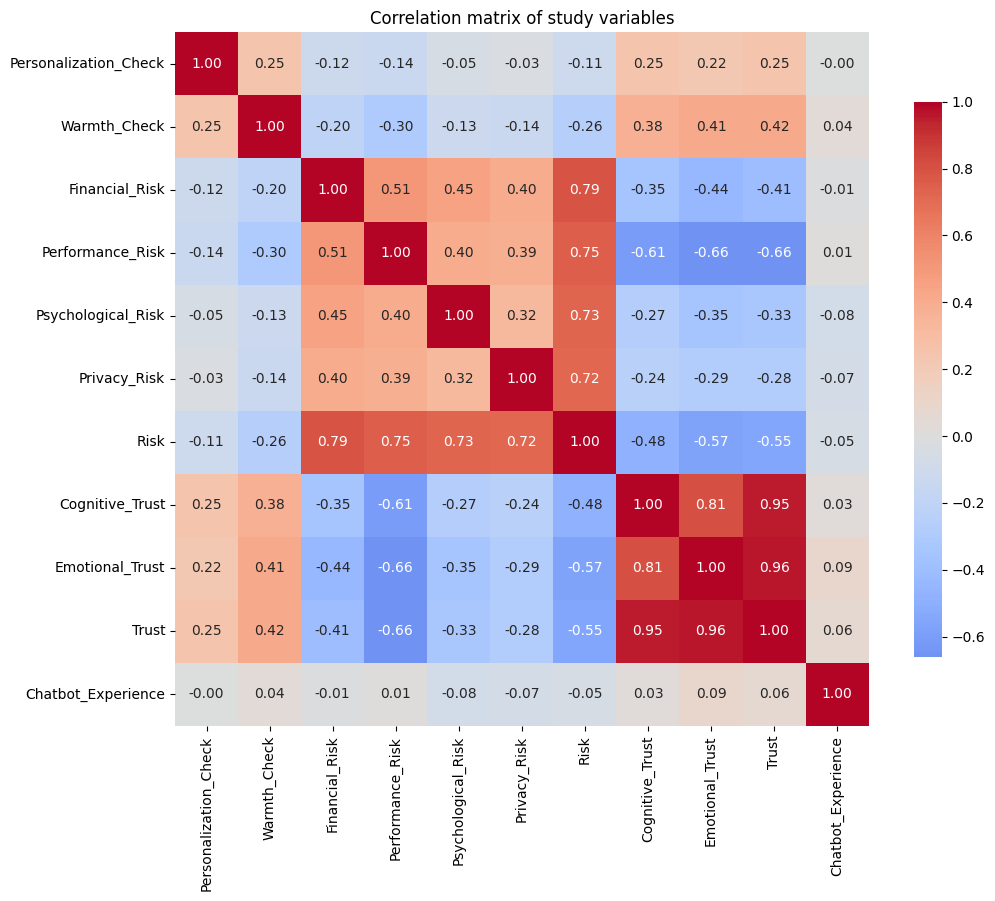

Saved Correlation_Matrix.csv and correlation_heatmap.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_vars = ["Personalization_Check", "Warmth_Check", "Financial_Risk", "Performance_Risk", "Psychological_Risk",
             "Privacy_Risk", "Risk", "Cognitive_Trust", "Emotional_Trust", "Trust", "Chatbot_Experience"]
corr = df[corr_vars].corr().round(2)
corr.to_csv(os.path.join(OUTPUT_DIR, "Correlation_Matrix.csv"))
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of study variables")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=150)
plt.show()
print("Saved Correlation_Matrix.csv and correlation_heatmap.png")

## 6. Hypothesis tests

### 6.1 Effects on each risk dimension (H1, H2, H3)
Factorial regression of each risk dimension and the overall index on personalization, conversation warmth, and their interaction, controlling for prior chatbot experience. Saved to Regression_RiskDimensions.csv.

In [11]:
risk_outcomes = ["Financial_Risk", "Performance_Risk", "Psychological_Risk", "Privacy_Risk", "Risk"]
reg_parts = []
for outcome in risk_outcomes:
    tbl, dfree = regression(df, outcome, ["personalization", "warmth", "Chatbot_Experience"], inter=[("personalization", "warmth")])
    print(f"\n===== {outcome} =====")
    print(tbl.round(4).to_string())
    t2 = tbl.round(4).copy(); t2.insert(0, "Outcome", outcome); reg_parts.append(t2)
pd.concat(reg_parts).to_csv(os.path.join(OUTPUT_DIR, "Regression_RiskDimensions.csv"))
print("\nSaved Regression_RiskDimensions.csv")


===== Financial_Risk =====
                             B      SE        t       p
term                                                   
Intercept               4.2203  0.2735  15.4283  0.0000
personalization        -0.1538  0.1700  -0.9043  0.3663
warmth                 -0.2541  0.1689  -1.5045  0.1330
Chatbot_Experience     -0.0069  0.0600  -0.1155  0.9081
personalization:warmth  0.6329  0.2393   2.6443  0.0084

===== Performance_Risk =====
                             B      SE        t       p
term                                                   
Intercept               4.9359  0.2443  20.2049  0.0000
personalization        -0.1783  0.1519  -1.1740  0.2409
warmth                 -0.1683  0.1509  -1.1155  0.2651
Chatbot_Experience      0.0076  0.0536   0.1424  0.8868
personalization:warmth  0.6141  0.2137   2.8730  0.0042

===== Psychological_Risk =====
                             B      SE        t       p
term                                                   
Intercept     

### 6.2 Effects on trust (H1b, H2b)
Trust regressed on personalization, conversation warmth, and their interaction, controlling for prior chatbot experience. Saved to Regression_Trust.csv.

In [12]:
trust_tbl, _ = regression(df, "Trust", ["personalization", "warmth", "Chatbot_Experience"], inter=[("personalization", "warmth")])
print(trust_tbl.round(4).to_string())
trust_tbl.round(4).to_csv(os.path.join(OUTPUT_DIR, "Regression_Trust.csv"))
print("\nSaved Regression_Trust.csv")

                             B      SE        t       p
term                                                   
Intercept               3.5120  0.2660  13.2009  0.0000
personalization         0.2106  0.1654   1.2737  0.2033
warmth                  0.0681  0.1643   0.4146  0.6786
Chatbot_Experience      0.0841  0.0584   1.4414  0.1501
personalization:warmth -0.5421  0.2328  -2.3291  0.0202

Saved Regression_Trust.csv


### 6.3 Independent variables and controls
Three specifications: personalization, conversation warmth, and their interaction (the product of the two 0/1 factors). In each, the other two design terms and prior chatbot experience are controls; the mediator is varied across the four dimensions and the overall index.

In [13]:
df["Warmth_x_Personalization"] = df["warmth"] * df["personalization"]
DESIGN = ["personalization", "warmth", "Warmth_x_Personalization"]
MEDIATORS = ["Financial_Risk", "Performance_Risk", "Psychological_Risk", "Privacy_Risk", "Risk"]
def controls_for(x): return [v for v in DESIGN if v != x] + ["Chatbot_Experience"]
for x in DESIGN: print(f"X = {x:24} controls = {controls_for(x)}")

X = personalization          controls = ['warmth', 'Warmth_x_Personalization', 'Chatbot_Experience']
X = warmth                   controls = ['personalization', 'Warmth_x_Personalization', 'Chatbot_Experience']
X = Warmth_x_Personalization controls = ['personalization', 'warmth', 'Chatbot_Experience']


### 6.4 Mediation through each risk dimension (H4)
PROCESS Model 4 indirect effect of each independent variable on trust through each risk dimension, with 5,000 percentile bootstrap samples. Saved to Mediation_AllDimensions.csv. The a and b columns are the cue-to-risk and risk-to-trust path coefficients.

In [14]:
med_rows = []
for x in DESIGN:
    for med in MEDIATORS:
        r = mediation_m4(df, x, med, "Trust", controls_for(x), boot=BOOT, seed=SEED)
        med_rows.append({"X": x, "Mediator": med, "a": round(r["a"], 3), "b": round(r["b"], 3),
                         "Indirect": round(r["indirect"], 3), "CI_95": f"[{r['lo']:.3f}, {r['hi']:.3f}]",
                         "Significant": "Yes" if r["sig"] else "No"})
        print(f"{x:24} {med:18} indirect = {r['indirect']:+.3f}  CI [{r['lo']:+.3f}, {r['hi']:+.3f}]  {'sig' if r['sig'] else 'ns'}")
mediation = pd.DataFrame(med_rows)
mediation.to_csv(os.path.join(OUTPUT_DIR, "Mediation_AllDimensions.csv"), index=False)
print("\n===== Mediation summary (Model 4) ====="); print(mediation.to_string(index=False))
print("\nSaved Mediation_AllDimensions.csv")
mediation

personalization          Financial_Risk     indirect = +0.061  CI [-0.072, +0.195]  ns
personalization          Performance_Risk   indirect = +0.128  CI [-0.094, +0.349]  ns
personalization          Psychological_Risk indirect = -0.052  CI [-0.163, +0.055]  ns
personalization          Privacy_Risk       indirect = -0.003  CI [-0.101, +0.092]  ns
personalization          Risk               indirect = +0.028  CI [-0.159, +0.212]  ns
warmth                   Financial_Risk     indirect = +0.101  CI [-0.026, +0.233]  ns
warmth                   Performance_Risk   indirect = +0.121  CI [-0.093, +0.318]  ns
warmth                   Psychological_Risk indirect = +0.001  CI [-0.105, +0.110]  ns
warmth                   Privacy_Risk       indirect = -0.012  CI [-0.104, +0.076]  ns
warmth                   Risk               indirect = +0.069  CI [-0.105, +0.245]  ns
Warmth_x_Personalization Financial_Risk     indirect = -0.251  CI [-0.446, -0.063]  sig
Warmth_x_Personalization Performance_Risk 

,X,Mediator,a,b,Indirect,CI_95,Significant
0,personalization,Financial_Risk,-0.154,-0.396,0.061,"[-0.072, 0.195]",No
1,personalization,Performance_Risk,-0.178,-0.719,0.128,"[-0.094, 0.349]",No
2,personalization,Psychological_Risk,0.165,-0.315,-0.052,"[-0.163, 0.055]",No
3,personalization,Privacy_Risk,0.014,-0.253,-0.003,"[-0.101, 0.092]",No
4,personalization,Risk,-0.038,-0.726,0.028,"[-0.159, 0.212]",No
5,warmth,Financial_Risk,-0.254,-0.396,0.101,"[-0.026, 0.233]",No
6,warmth,Performance_Risk,-0.168,-0.719,0.121,"[-0.093, 0.318]",No
7,warmth,Psychological_Risk,-0.004,-0.315,0.001,"[-0.105, 0.110]",No
8,warmth,Privacy_Risk,0.047,-0.253,-0.012,"[-0.104, 0.076]",No
9,warmth,Risk,-0.095,-0.726,0.069,"[-0.105, 0.245]",No


### 6.5 Moderated mediation by domain (H5, H6)
PROCESS Model 7 index of moderated mediation and the conditional indirect effects in the retail and financial domains, for each independent variable and risk dimension. Saved to ModeratedMediation_AllDimensions.csv.

In [15]:
mod_rows = []
for x in DESIGN:
    for med in MEDIATORS:
        r = mediation_m7(df, x, med, "Trust", "domain_num", controls_for(x), boot=BOOT, seed=SEED)
        mod_rows.append({"X": x, "Mediator": med, "Index": round(r["index"], 3),
                         "CI_95": f"[{r['ilo']:.3f}, {r['ihi']:.3f}]", "Significant": "Yes" if r["index_sig"] else "No",
                         "Indirect_retail": round(r["cond0"], 3), "CI_retail": f"[{r['c0lo']:.3f}, {r['c0hi']:.3f}]",
                         "Indirect_financial": round(r["cond1"], 3), "CI_financial": f"[{r['c1lo']:.3f}, {r['c1hi']:.3f}]"})
        print(f"{x:24} {med:18} index = {r['index']:+.3f}  CI [{r['ilo']:+.3f}, {r['ihi']:+.3f}]  {'sig' if r['index_sig'] else 'ns'}")
modmed = pd.DataFrame(mod_rows)
modmed.to_csv(os.path.join(OUTPUT_DIR, "ModeratedMediation_AllDimensions.csv"), index=False)
print("\n===== Moderated mediation summary (Model 7) ====="); print(modmed.to_string(index=False))
print("\nSaved ModeratedMediation_AllDimensions.csv")
modmed

personalization          Financial_Risk     index = -0.067  CI [-0.249, +0.115]  ns
personalization          Performance_Risk   index = +0.070  CI [-0.242, +0.371]  ns
personalization          Psychological_Risk index = +0.009  CI [-0.136, +0.160]  ns
personalization          Privacy_Risk       index = -0.055  CI [-0.186, +0.066]  ns
personalization          Risk               index = -0.047  CI [-0.302, +0.192]  ns
warmth                   Financial_Risk     index = -0.094  CI [-0.274, +0.082]  ns
warmth                   Performance_Risk   index = +0.011  CI [-0.289, +0.309]  ns
warmth                   Psychological_Risk index = -0.177  CI [-0.342, -0.034]  sig
warmth                   Privacy_Risk       index = -0.104  CI [-0.238, +0.016]  ns
warmth                   Risk               index = -0.217  CI [-0.460, +0.024]  ns
Warmth_x_Personalization Financial_Risk     index = -0.135  CI [-0.350, +0.072]  ns
Warmth_x_Personalization Performance_Risk   index = +0.100  CI [-0.244, +0.

,X,Mediator,Index,CI_95,Significant,Indirect_retail,CI_retail,Indirect_financial,CI_financial
0,personalization,Financial_Risk,-0.067,"[-0.249, 0.115]",No,0.090,"[-0.076, 0.258]",0.023,"[-0.130, 0.175]"
1,personalization,Performance_Risk,0.070,"[-0.242, 0.371]",No,0.092,"[-0.185, 0.365]",0.162,"[-0.094, 0.429]"
2,personalization,Psychological_Risk,0.009,"[-0.136, 0.160]",No,-0.059,"[-0.192, 0.071]",-0.050,"[-0.180, 0.078]"
3,personalization,Privacy_Risk,-0.055,"[-0.186, 0.066]",No,0.023,"[-0.087, 0.132]",-0.033,"[-0.154, 0.083]"
4,personalization,Risk,-0.047,"[-0.302, 0.192]",No,0.047,"[-0.171, 0.269]",-0.001,"[-0.226, 0.223]"
5,warmth,Financial_Risk,-0.094,"[-0.274, 0.082]",No,0.138,"[-0.020, 0.304]",0.044,"[-0.107, 0.195]"
6,warmth,Performance_Risk,0.011,"[-0.289, 0.309]",No,0.114,"[-0.156, 0.364]",0.125,"[-0.132, 0.380]"
7,warmth,Psychological_Risk,-0.177,"[-0.342, -0.034]",Yes,0.084,"[-0.043, 0.221]",-0.093,"[-0.227, 0.033]"
8,warmth,Privacy_Risk,-0.104,"[-0.238, 0.016]",No,0.036,"[-0.067, 0.141]",-0.068,"[-0.188, 0.040]"
9,warmth,Risk,-0.217,"[-0.460, 0.024]",No,0.166,"[-0.043, 0.376]",-0.051,"[-0.264, 0.167]"


### 6.6 Hypothesis summary and verdicts
Explicit verdicts for the main hypotheses on overall risk and trust. Saved to Hypothesis_Results.csv.

In [16]:
risk_tbl, _ = regression(df, "Risk", ["personalization", "warmth", "Chatbot_Experience"], inter=[("personalization", "warmth")])
h5p, _ = regression(df, "Risk", ["personalization", "domain_num", "warmth", "Chatbot_Experience"], inter=[("personalization", "domain_num")])
h5w, _ = regression(df, "Risk", ["warmth", "domain_num", "personalization", "Chatbot_Experience"], inter=[("warmth", "domain_num")])
def gt(tbl, term):
    return (round(float(tbl.loc[term, "B"]), 3), round(float(tbl.loc[term, "p"]), 4)) if term in tbl.index else (None, None)
EXPECT = {"H1a": "-", "H2a": "-", "H3": "-", "H1b": "+", "H2b": "+"}
def vreg(h, b, p):
    if b is None or p is None: return "n/a"
    if p >= .05: return "Not supported"
    return "Supported" if (("+" if b > 0 else "-") == EXPECT[h]) else "Supported (Two tailed)"
def overall(tbl, x):
    r = tbl[(tbl["X"] == x) & (tbl["Mediator"] == "Risk")]
    return r.iloc[0] if len(r) else None
rows = []
b, p = gt(risk_tbl, "personalization");        rows.append(["H1a", "Personalization lowers overall risk", f"B = {b}", f"p = {p}", vreg("H1a", b, p)])
b, p = gt(risk_tbl, "warmth");                 rows.append(["H2a", "Warmth lowers overall risk", f"B = {b}", f"p = {p}", vreg("H2a", b, p)])
b, p = gt(risk_tbl, "personalization:warmth"); rows.append(["H3", "Personalization x warmth lowers overall risk", f"B = {b}", f"p = {p}", vreg("H3", b, p)])
b, p = gt(trust_tbl, "personalization");        rows.append(["H1b", "Personalization raises trust", f"B = {b}", f"p = {p}", vreg("H1b", b, p)])
b, p = gt(trust_tbl, "warmth");                 rows.append(["H2b", "Warmth raises trust", f"B = {b}", f"p = {p}", vreg("H2b", b, p)])
for h, x in [("H4a", "personalization"), ("H4b", "warmth")]:
    r = overall(mediation, x)
    if r is not None: rows.append([h, "Overall risk mediates " + x + " -> trust", "indirect = " + str(r["Indirect"]), r["CI_95"], "Supported" if r["Significant"] == "Yes" else "Not supported"])
b, p = gt(h5p, "personalization:domain_num"); rows.append(["H5a", "Domain moderates personalization -> risk", f"B = {b}", f"p = {p}", "Supported" if (p is not None and p < .05) else "Not supported"])
b, p = gt(h5w, "warmth:domain_num");          rows.append(["H5b", "Domain moderates warmth -> risk", f"B = {b}", f"p = {p}", "Supported" if (p is not None and p < .05) else "Not supported"])
for h, x in [("H6a", "personalization"), ("H6b", "warmth")]:
    r = overall(modmed, x)
    if r is not None: rows.append([h, "Indirect effect of " + x + " differs by domain", "index = " + str(r["Index"]), r["CI_95"], "Supported" if r["Significant"] == "Yes" else "Not supported"])
verdicts = pd.DataFrame(rows, columns=["Hypothesis", "Description", "Estimate", "p_or_CI", "Verdict"])
verdicts.to_csv(os.path.join(OUTPUT_DIR, "Hypothesis_Results.csv"), index=False)
print(verdicts.to_string(index=False))
print("\nVERDICTS")
for r in rows: print(f"  {r[0]:5} {r[4]:32} {r[1]}")
print("\nSaved Hypothesis_Results.csv")
verdicts

Hypothesis                                          Description         Estimate         p_or_CI                Verdict
       H1a                  Personalization lowers overall risk       B = -0.038      p = 0.7574          Not supported
       H2a                           Warmth lowers overall risk       B = -0.095      p = 0.4432          Not supported
        H3         Personalization x warmth lowers overall risk        B = 0.367      p = 0.0367 Supported (Two tailed)
       H1b                         Personalization raises trust        B = 0.211      p = 0.2033          Not supported
       H2b                                  Warmth raises trust        B = 0.068      p = 0.6786          Not supported
       H4a       Overall risk mediates personalization -> trust indirect = 0.028 [-0.159, 0.212]          Not supported
       H4b                Overall risk mediates warmth -> trust indirect = 0.069 [-0.105, 0.245]          Not supported
       H5a             Domain moderates 

,Hypothesis,Description,Estimate,p_or_CI,Verdict
0,H1a,Personalization lowers overall risk,B = -0.038,p = 0.7574,Not supported
1,H2a,Warmth lowers overall risk,B = -0.095,p = 0.4432,Not supported
2,H3,Personalization x warmth lowers overall risk,B = 0.367,p = 0.0367,Supported (Two tailed)
3,H1b,Personalization raises trust,B = 0.211,p = 0.2033,Not supported
4,H2b,Warmth raises trust,B = 0.068,p = 0.6786,Not supported
5,H4a,Overall risk mediates personalization -> trust,indirect = 0.028,"[-0.159, 0.212]",Not supported
6,H4b,Overall risk mediates warmth -> trust,indirect = 0.069,"[-0.105, 0.245]",Not supported
7,H5a,Domain moderates personalization -> risk,B = 0.062,p = 0.72,Not supported
8,H5b,Domain moderates warmth -> risk,B = 0.302,p = 0.0806,Not supported
9,H6a,Indirect effect of personalization differs by ...,index = -0.047,"[-0.302, 0.192]",Not supported


## 7. Significant paths
The full chain restricted to significant effects: a-paths (cue or interaction to a risk dimension, p < .05), b-paths (risk dimension to trust, p < .05), indirect effects (Model 4, bootstrap interval excludes zero), and any index of moderated mediation (Model 7, interval excludes zero). Saved to Significant_Paths.csv.

In [17]:
sig_rows = []
a_labels = {"personalization": "Personalization", "warmth": "Warmth", "personalization:warmth": "Personalization x Warmth"}
for dim in MEDIATORS:
    tbl, _ = regression(df, dim, ["personalization", "warmth", "Chatbot_Experience"], inter=[("personalization", "warmth")])
    for term, nice in a_labels.items():
        if term in tbl.index and tbl.loc[term, "p"] < .05:
            b = float(tbl.loc[term, "B"])
            sig_rows.append({"Effect": f"{nice} -> {dim}", "Type": "a-path (cue -> risk)", "Estimate": round(b, 3),
                             "p_or_CI": f"p = {tbl.loc[term, 'p']:.4f}", "Meaning": "raises risk" if b > 0 else "lowers risk"})
for dim in MEDIATORS:
    tbl, _ = regression(df, "Trust", [dim, "personalization", "warmth", "Chatbot_Experience"])
    if tbl.loc[dim, "p"] < .05:
        b = float(tbl.loc[dim, "B"])
        sig_rows.append({"Effect": f"{dim} -> Trust", "Type": "b-path (risk -> trust)", "Estimate": round(b, 3),
                         "p_or_CI": f"p = {tbl.loc[dim, 'p']:.4f}", "Meaning": "raises trust" if b > 0 else "lowers trust"})
for _, r in mediation.iterrows():
    if r["Significant"] == "Yes":
        sig_rows.append({"Effect": f'{r["X"]} -> {r["Mediator"]} -> Trust', "Type": "indirect (mediation)",
                         "Estimate": r["Indirect"], "p_or_CI": r["CI_95"],
                         "Meaning": "lowers trust via risk" if float(r["Indirect"]) < 0 else "raises trust via risk"})
for _, r in modmed.iterrows():
    if r["Significant"] == "Yes":
        sig_rows.append({"Effect": f'{r["X"]} x domain -> {r["Mediator"]} -> Trust', "Type": "index of moderated mediation",
                         "Estimate": r["Index"], "p_or_CI": r["CI_95"], "Meaning": "indirect effect differs by domain"})
sig = pd.DataFrame(sig_rows, columns=["Effect", "Type", "Estimate", "p_or_CI", "Meaning"])
sig.to_csv(os.path.join(OUTPUT_DIR, "Significant_Paths.csv"), index=False)
print("Significant paths (p < .05 or 95% bootstrap CI excludes zero):")
print(sig.to_string(index=False) if len(sig) else "  none")
print("\nSaved Significant_Paths.csv")
sig

Significant paths (p < .05 or 95% bootstrap CI excludes zero):
                                               Effect                         Type  Estimate          p_or_CI                           Meaning
           Personalization x Warmth -> Financial_Risk         a-path (cue -> risk)     0.633       p = 0.0084                       raises risk
         Personalization x Warmth -> Performance_Risk         a-path (cue -> risk)     0.614       p = 0.0042                       raises risk
                     Personalization x Warmth -> Risk         a-path (cue -> risk)     0.367       p = 0.0367                       raises risk
                              Financial_Risk -> Trust       b-path (risk -> trust)    -0.402       p = 0.0000                      lowers trust
                            Performance_Risk -> Trust       b-path (risk -> trust)    -0.721       p = 0.0000                      lowers trust
                          Psychological_Risk -> Trust       b-path (risk 

,Effect,Type,Estimate,p_or_CI,Meaning
0,Personalization x Warmth -> Financial_Risk,a-path (cue -> risk),0.633,p = 0.0084,raises risk
1,Personalization x Warmth -> Performance_Risk,a-path (cue -> risk),0.614,p = 0.0042,raises risk
2,Personalization x Warmth -> Risk,a-path (cue -> risk),0.367,p = 0.0367,raises risk
3,Financial_Risk -> Trust,b-path (risk -> trust),-0.402,p = 0.0000,lowers trust
4,Performance_Risk -> Trust,b-path (risk -> trust),-0.721,p = 0.0000,lowers trust
5,Psychological_Risk -> Trust,b-path (risk -> trust),-0.316,p = 0.0000,lowers trust
6,Privacy_Risk -> Trust,b-path (risk -> trust),-0.256,p = 0.0000,lowers trust
7,Risk -> Trust,b-path (risk -> trust),-0.732,p = 0.0000,lowers trust
8,Warmth_x_Personalization -> Financial_Risk -> ...,indirect (mediation),-0.251,"[-0.446, -0.063]",lowers trust via risk
9,Warmth_x_Personalization -> Performance_Risk -...,indirect (mediation),-0.441,"[-0.742, -0.137]",lowers trust via risk


## 8. Assumption checks and diagnostic plots
Regression assumptions for the main perceived-risk model (risk on personalization, warmth, their interaction, and prior chatbot experience): residual normality with a normal P-P plot, homoscedasticity with the Breusch-Pagan test, and multicollinearity with variance inflation factors. The significant personalization*warmth interaction is also plotted. Figures are saved to the CSV outputs folder.

Residual normality: skewness = -0.312, excess kurtosis = 0.106
Breusch-Pagan heteroscedasticity test: LM = 3.987, df = 4, p = 0.409
VIF personalization      = 2.02
VIF warmth               = 2.00
VIF pers*warm            = 2.98
VIF Chatbot_Experience   = 1.00


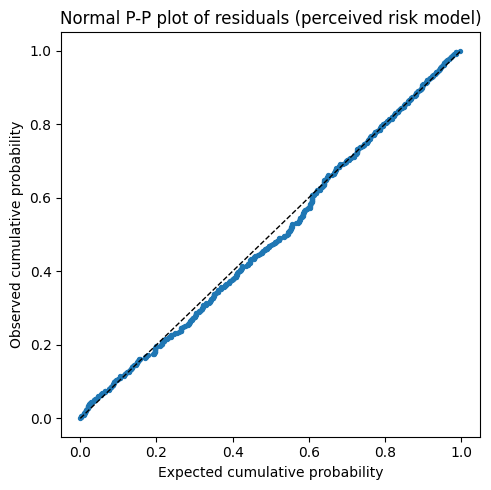

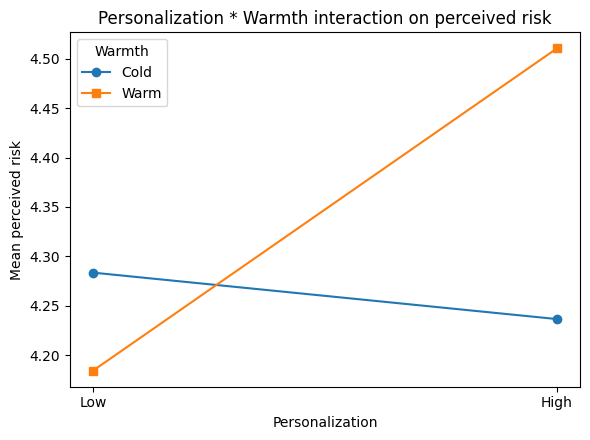

Saved PP_plot_risk_model.png and Interaction_plot_risk.png


In [18]:
import matplotlib.pyplot as plt, math
pp = df["personalization"].astype(float).values
ww = df["warmth"].astype(float).values
ce = df["Chatbot_Experience"].astype(float).values
yy = df["Risk"].values
Xa = np.column_stack([np.ones(len(df)), pp, ww, pp * ww, ce])
bb, *_ = np.linalg.lstsq(Xa, yy, rcond=None); res = yy - Xa @ bb
def _Phi(z): return 0.5 * (1 + math.erf(z / math.sqrt(2)))
zr = (res - res.mean()) / res.std(ddof=1)
print(f"Residual normality: skewness = {np.mean(zr**3):.3f}, excess kurtosis = {np.mean(zr**4) - 3:.3f}")
r2 = res**2; cb, *_ = np.linalg.lstsq(Xa, r2, rcond=None); prc = Xa @ cb
R2bp = 1 - ((r2 - prc)**2).sum() / ((r2 - r2.mean())**2).sum(); LM = len(df) * R2bp; k = Xa.shape[1] - 1
xk = LM / k; p_bp = 1 - _Phi(((xk)**(1/3) - (1 - 2/(9*k))) / math.sqrt(2/(9*k)))
print(f"Breusch-Pagan heteroscedasticity test: LM = {LM:.3f}, df = {k}, p = {p_bp:.3f}")
cols = {"personalization": pp, "warmth": ww, "pers*warm": pp*ww, "Chatbot_Experience": ce}
ks = list(cols); Mx = np.column_stack([cols[c] for c in ks])
for i, c in enumerate(ks):
    yj = Mx[:, i]; Xj = np.column_stack([np.ones(len(df))] + [Mx[:, j] for j in range(Mx.shape[1]) if j != i])
    bj, *_ = np.linalg.lstsq(Xj, yj, rcond=None); rj = yj - Xj @ bj
    R2j = 1 - ((rj**2).sum() / (((yj - yj.mean())**2).sum())); print(f"VIF {c:20} = {1/(1-R2j):.2f}")
rs = np.sort(res); emp = (np.arange(1, len(df)+1) - 0.5) / len(df)
theo = np.array([_Phi(t) for t in (rs - res.mean()) / res.std(ddof=1)])
plt.figure(figsize=(5,5)); plt.plot([0,1],[0,1],"k--",lw=1); plt.scatter(theo, emp, s=8)
plt.xlabel("Expected cumulative probability"); plt.ylabel("Observed cumulative probability")
plt.title("Normal P-P plot of residuals (perceived risk model)"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "PP_plot_risk_model.png"), dpi=150); plt.show()
cell = df.groupby(["personalization","warmth"])["Risk"].mean().unstack()
plt.figure(figsize=(6,4.5))
for wv, lab, mk in [(0,"Cold","o-"),(1,"Warm","s-")]:
    plt.plot([0,1],[cell.loc[0,wv], cell.loc[1,wv]], mk, label=lab)
plt.xticks([0,1],["Low","High"]); plt.xlabel("Personalization"); plt.ylabel("Mean perceived risk")
plt.title("Personalization * Warmth interaction on perceived risk"); plt.legend(title="Warmth"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Interaction_plot_risk.png"), dpi=150); plt.show()
print("Saved PP_plot_risk_model.png and Interaction_plot_risk.png")

Residual normality: skewness=-0.312, excess kurtosis=0.106
Breusch-Pagan: LM=3.987, df=4, p=0.409
VIF personalization     =2.02
VIF warmth              =2.00
VIF pers*warm           =2.98
VIF Chatbot_Experience  =1.00
Interaction effect size on overall risk: deltaR2=0.0081, Cohen f2=0.0082


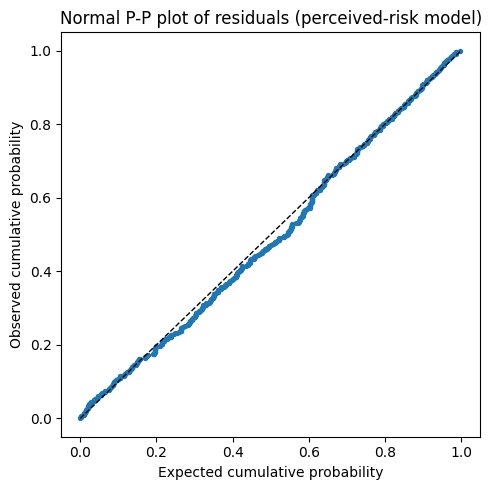

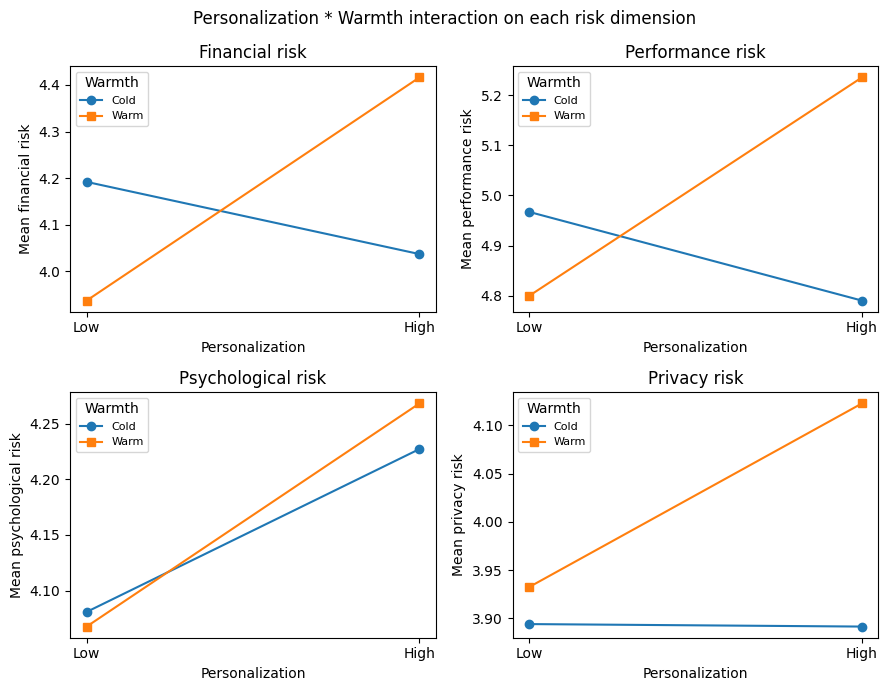


8-condition means/SD:
   Domain Personalization Warmth  n  Risk_M  Risk_SD  Trust_M  Trust_SD
Financial             Low   Cold 67    4.39     1.07     3.90      1.22
Financial             Low   Warm 66    4.45     0.90     3.96      1.27
Financial            High   Cold 67    4.38     0.98     4.05      1.19
Financial            High   Warm 67    4.78     0.92     3.68      1.25
   Retail             Low   Cold 65    4.17     1.00     3.82      1.54
   Retail             Low   Warm 72    3.94     1.01     3.90      1.37
   Retail            High   Cold 68    4.10     1.08     4.11      1.42
   Retail            High   Warm 66    4.23     1.01     3.52      1.53

Saved PP_plot_risk_model.png, Interaction_by_dimension.png, Cell_Means_8conditions.csv


In [21]:
import matplotlib.pyplot as plt, math
pp=df["personalization"].astype(float).values; ww=df["warmth"].astype(float).values
ce=df["Chatbot_Experience"].astype(float).values; yy=df["Risk"].values
Xa=np.column_stack([np.ones(len(df)),pp,ww,pp*ww,ce]); bb,*_=np.linalg.lstsq(Xa,yy,rcond=None); res=yy-Xa@bb
def _Phi(z): return 0.5*(1+math.erf(z/math.sqrt(2)))
zr=(res-res.mean())/res.std(ddof=1)
print(f"Residual normality: skewness={np.mean(zr**3):.3f}, excess kurtosis={np.mean(zr**4)-3:.3f}")
r2=res**2; cb,*_=np.linalg.lstsq(Xa,r2,rcond=None); prc=Xa@cb
R2bp=1-((r2-prc)**2).sum()/((r2-r2.mean())**2).sum(); LM=len(df)*R2bp; k=Xa.shape[1]-1
xk=LM/k; p_bp=1-_Phi(((xk)**(1/3)-(1-2/(9*k)))/math.sqrt(2/(9*k)))
print(f"Breusch-Pagan: LM={LM:.3f}, df={k}, p={p_bp:.3f}")
cols={"personalization":pp,"warmth":ww,"pers*warm":pp*ww,"Chatbot_Experience":ce}; ks=list(cols); Mx=np.column_stack([cols[c] for c in ks])
for i,c in enumerate(ks):
    yj=Mx[:,i]; Xj=np.column_stack([np.ones(len(df))]+[Mx[:,j] for j in range(Mx.shape[1]) if j!=i])
    bj,*_=np.linalg.lstsq(Xj,yj,rcond=None); rj=yj-Xj@bj; R2j=1-((rj**2).sum()/(((yj-yj.mean())**2).sum())); print(f"VIF {c:20}={1/(1-R2j):.2f}")
# effect size of the interaction on overall risk
def _r2(y,X): b,*_=np.linalg.lstsq(X,y,rcond=None); r=y-X@b; return 1-(r@r)/(((y-y.mean())**2).sum())
R2f=_r2(yy,Xa); R2r=_r2(yy,np.column_stack([np.ones(len(df)),pp,ww,ce])); f2=(R2f-R2r)/(1-R2f)
print(f"Interaction effect size on overall risk: deltaR2={R2f-R2r:.4f}, Cohen f2={f2:.4f}")
# P-P plot
rs=np.sort(res); emp=(np.arange(1,len(df)+1)-0.5)/len(df); theo=np.array([_Phi(t) for t in (rs-res.mean())/res.std(ddof=1)])
plt.figure(figsize=(5,5)); plt.plot([0,1],[0,1],"k--",lw=1); plt.scatter(theo,emp,s=8)
plt.xlabel("Expected cumulative probability"); plt.ylabel("Observed cumulative probability"); plt.title("Normal P-P plot of residuals (perceived-risk model)")
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,"PP_plot_risk_model.png"),dpi=150); plt.show()
# combined per-dimension interaction figure (one identical y-axis on all panels, global min to max)
dims=[("Financial_Risk","Financial risk"),("Performance_Risk","Performance risk"),("Psychological_Risk","Psychological risk"),("Privacy_Risk","Privacy risk")]
_cells={d:df.groupby(["personalization","warmth"])[d].mean().unstack() for d,_ in dims}
_gmin=min(c.values.min() for c in _cells.values()); _gmax=max(c.values.max() for c in _cells.values()); _pad=(_gmax-_gmin)*0.08
fig,axes=plt.subplots(2,2,figsize=(9,7))
for ax,(dim,lab) in zip(axes.ravel(),dims):
    cell=_cells[dim]
    for wv,wl,mk in [(0,"Cold","o-"),(1,"Warm","s-")]: ax.plot([0,1],[cell.loc[0,wv],cell.loc[1,wv]],mk,label=wl)
    ax.set_ylim(_gmin-_pad, _gmax+_pad)   # same absolute scale on every panel for true comparability
    ax.set_xticks([0,1]); ax.set_xticklabels(["Low","High"]); ax.set_xlabel("Personalization"); ax.set_ylabel("Mean "+lab.lower()); ax.set_title(lab); ax.legend(title="Warmth",fontsize=8)
fig.suptitle("Personalization * Warmth interaction on each risk dimension"); fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,"Interaction_by_dimension.png"),dpi=150); plt.show()
# 8-condition means/SD table
rows=[]
for (dom,pe,wa),sub in df.groupby(["domain","personalization","warmth"]):
    rows.append({"Domain":dom.capitalize(),"Personalization":"High" if pe==1 else "Low","Warmth":"Warm" if wa==1 else "Cold","n":len(sub),
                 "Risk_M":round(sub["Risk"].mean(),2),"Risk_SD":round(sub["Risk"].std(),2),"Trust_M":round(sub["Trust"].mean(),2),"Trust_SD":round(sub["Trust"].std(),2)})
celltab=pd.DataFrame(rows); celltab.to_csv(os.path.join(OUTPUT_DIR,"Cell_Means_8conditions.csv"),index=False)
print("\n8-condition means/SD:"); print(celltab.to_string(index=False))
print("\nSaved PP_plot_risk_model.png, Interaction_by_dimension.png, Cell_Means_8conditions.csv")

## Output files
Written to the CSV outputs folder: Reliability.csv, Manipulation_Checks.csv, Descriptives.csv, Demographics_Table.csv, Correlation_Matrix.csv, correlation_heatmap.png, Regression_RiskDimensions.csv, Regression_Trust.csv, Mediation_AllDimensions.csv, ModeratedMediation_AllDimensions.csv, Hypothesis_Results.csv, and Significant_Paths.csv.